In [32]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import unicodedata
import matplotlib.font_manager as fm
import matplotlib.patheffects as path_effects
import datetime
import time
import numpy as np

In [33]:
#한글 폰트 설정
font_path = 'NotoSansKR-Regular.ttf'
fontprop = fm.FontProperties(fname=font_path)
plt.rc('font', family=fontprop.get_name())

In [34]:
#데이터 경로 설정
base_folder = '/Users/limtae-kyu/data-analysis'
folders = ['광야', '돌산', '돔구장', '돔자연짬', '말미잘', '오아시스', '옹기종기', '유적지', '철탑', '터널']

In [35]:
import pandas as pd
import os

# 데이터 경로 설정
base_folder = '/Users/limtae-kyu/data-analysis'
folders = ['광야', '돌산', '돔구장', '돔자연짬', '말미잘', '오아시스', '옹기종기', '유적지', '철탑', '터널']

all_data = []
max_depths = []
diving_times = []

for folder in folders:
    folder_path = os.path.join(base_folder, folder)
    if os.path.isdir(folder_path):
        for filename in os.listdir(folder_path):
            if filename.endswith('.csv'):
                file_path = os.path.join(folder_path, filename)

                # 첫 두 행을 별도로 읽기
                with open(file_path, 'r') as file:
                    first_two_lines = [file.readline().strip() for _ in range(2)]
                    columns = first_two_lines[0].split(',')
                    values = first_two_lines[1].split(',')

                    # Start Date와 End Date 초기화
                    Start_date_value = None
                    End_date_value = None

                    if 'Start Date' in columns:
                        Start_date_index = columns.index('Start Date')
                        Start_date_value = values[Start_date_index]

                    if 'End Date' in columns:
                        End_date_index = columns.index('End Date')
                        End_date_value = values[End_date_index]

                    # Diving Time 계산
                    if Start_date_value and End_date_value:
                        date_formats = ['%m/%d/%Y %I:%M:%S %p', '%m/%d/%Y %H:%M:%S']
                        Start_datetime = None
                        End_datetime = None

                        for date_format in date_formats:
                            try:
                                Start_datetime = pd.to_datetime(Start_date_value, format=date_format)
                                End_datetime = pd.to_datetime(End_date_value, format=date_format)
                                if Start_datetime is not pd.NaT and End_datetime is not pd.NaT:
                                    break
                            except ValueError:
                                continue

                        if Start_datetime and End_datetime:
                            diving_time = (End_datetime - Start_datetime).total_seconds() / 60  # 분 단위
                            diving_times.append((filename, diving_time))

                # 세 번째 행부터 데이터 읽기
                df = pd.read_csv(file_path, skiprows=2)
                all_data.append(df)

                # Max Depth 찾기
                possible_columns = ['Max Depth', 'Depth', 'Maximum Depth']
                max_depth_column = next((col for col in possible_columns if col in df.columns), None)
                if max_depth_column:
                    max_depth = df[max_depth_column].max()
                    max_depths.append((filename, max_depth))

# diving_times를 데이터프레임으로 변환
diving_times_df = pd.DataFrame(diving_times, columns=["Filename", "Diving Time"])
print(diving_times_df)


                            Filename  Diving Time
0       #133 2024-8-2 12-15-6-광야.csv    23.816667
1     #125 2024-7-27 13-55-45-광야.csv    24.616667
2     #104 2024-7-12 11-10-48-돌산.csv    30.616667
3     #128 2024-7-28 14-30-24-돌산.csv    24.400000
4      #147 2024-8-9 14-15-33-돌산.csv    23.350000
5        #94 2024-7-6 9-13-44-돌산.csv    32.850000
6      #132 2024-8-2 10-21-27-돌산.csv    36.750000
7      #144 2024-8-8 11-50-11-돌산.csv    35.400000
8      #135 2024-8-2 15-59-28-돌산.csv     6.333333
9     #109 2024-7-13 14-59-55-돌산.csv    35.583333
10     #112 2024-7-19 11-2-47-돌산.csv    28.800000
11      #88 2024-6-29 9-19-17-돌산.csv    34.366667
12    #110 2024-7-13 16-52-22-돌산.csv    23.166667
13      #123 2024-7-27 9-19-9-돌산.csv    35.983333
14    #164 2024-8-18 11-25-31-돌산.csv    34.883333
15      #130 2024-8-1 15-0-56-돌산.csv    38.266667
16     #152 2024-8-15 9-16-53-돌산.csv    31.033333
17    #159 2024-8-16 15-35-34-돌산.csv    20.700000
18    #120 2024-7-26 10-25-19-돌산.csv    18.316667


In [36]:
# 최대 깊이 정보 요약
if max_depths:
    max_depths_df = pd.DataFrame(max_depths, columns=['Filename', 'Max Depth'])
    pd.set_option('display.max_rows', None)  # 모든 행을 표시하도록 설정
    print(max_depths_df.to_string(index=False))
else:
    print("null")


                        Filename  Max Depth
    #133 2024-8-2 12-15-6-광야.csv  34.600000
  #125 2024-7-27 13-55-45-광야.csv  28.500000
  #104 2024-7-12 11-10-48-돌산.csv   8.800000
  #128 2024-7-28 14-30-24-돌산.csv   5.700000
   #147 2024-8-9 14-15-33-돌산.csv   8.400001
     #94 2024-7-6 9-13-44-돌산.csv   9.400001
   #132 2024-8-2 10-21-27-돌산.csv  10.600000
   #144 2024-8-8 11-50-11-돌산.csv  10.100000
   #135 2024-8-2 15-59-28-돌산.csv   4.500000
  #109 2024-7-13 14-59-55-돌산.csv   9.900001
   #112 2024-7-19 11-2-47-돌산.csv  10.600000
    #88 2024-6-29 9-19-17-돌산.csv  10.300000
  #110 2024-7-13 16-52-22-돌산.csv   8.800000
    #123 2024-7-27 9-19-9-돌산.csv   9.100000
  #164 2024-8-18 11-25-31-돌산.csv   8.900001
    #130 2024-8-1 15-0-56-돌산.csv   9.400001
   #152 2024-8-15 9-16-53-돌산.csv   8.900001
  #159 2024-8-16 15-35-34-돌산.csv   9.400001
  #120 2024-7-26 10-25-19-돌산.csv   8.700000
  #111 2024-7-19 9-31-42-돔구장.csv  17.000000
 #165 2024-8-18 14-46-49-돔구장.csv  22.200000
 #162 2024-8-17 14-11-20-돔구장.csv

In [37]:
# 최대 수심이 깊은 상위 1-10위
if max_depths:
    max_depths_df = pd.DataFrame(max_depths, columns=['Filename', 'Max Depth'])
    top_10_max_depths = max_depths_df.nlargest(10, 'Max Depth')
    print(top_10_max_depths.to_string(index=False))

                       Filename  Max Depth
   #133 2024-8-2 12-15-6-광야.csv       34.6
#116 2024-7-20 11-11-21-말미잘.csv       32.0
 #134 2024-8-2 14-45-19-말미잘.csv       30.0
 #156 2024-8-16 12-51-9-말미잘.csv       30.0
#161 2024-8-17 11-40-23-말미잘.csv       29.0
 #125 2024-7-27 13-55-45-광야.csv       28.5
  #99 2024-7-7 11-43-34-말미잘.csv       28.1
   #140 2024-8-3 12-36-8-철탑.csv       28.0
 #105 2024-7-12 13-44-50-철탑.csv       27.5
 #154 2024-8-16 10-31-55-철탑.csv       27.3


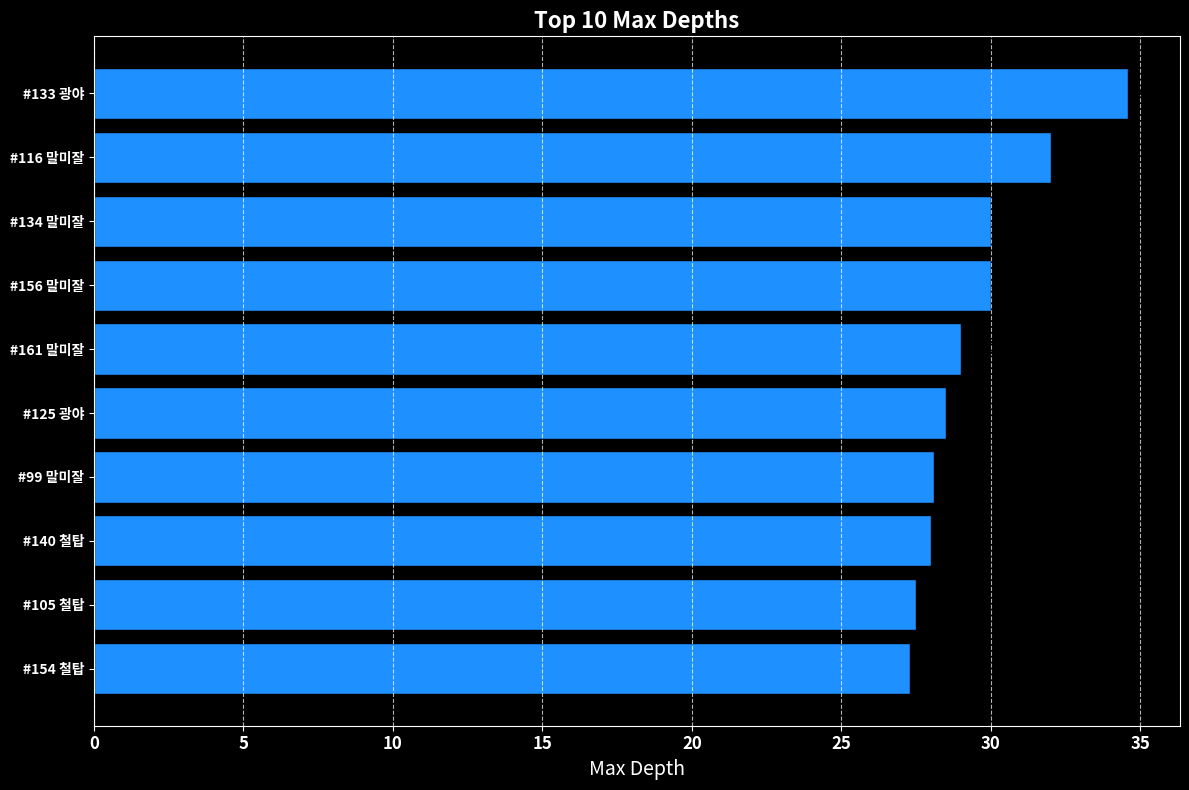

In [38]:
# 시각화 추가
plt.figure(figsize=(12, 8))  # 그래프 크기 조정
plt.barh(top_10_max_depths['Filename'].apply(lambda x: f'{x.split(" ")[0]} {x.split("-")[-1].split(".")[0]}'), top_10_max_depths['Max Depth'], color='dodgerblue', edgecolor='black')

# 막대 끝에 수치 추가
for index, value in enumerate(top_10_max_depths['Max Depth']):
    plt.text(value, index, f'{value:.1f}', va='center', fontsize=12, color='black', fontweight='bold')
plt.xlabel('Max Depth', fontsize=14)
plt.title('Top 10 Max Depths', fontsize=16, fontweight='bold')
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=10, fontweight='bold' )
plt.gca().invert_yaxis()  # 수평 막대그래프에서 큰 값이 위로 오도록 설정
plt.grid(axis='x', linestyle='--', alpha=0.7)  # 가독성을 위한 그리드 추가
plt.tight_layout()
plt.show()


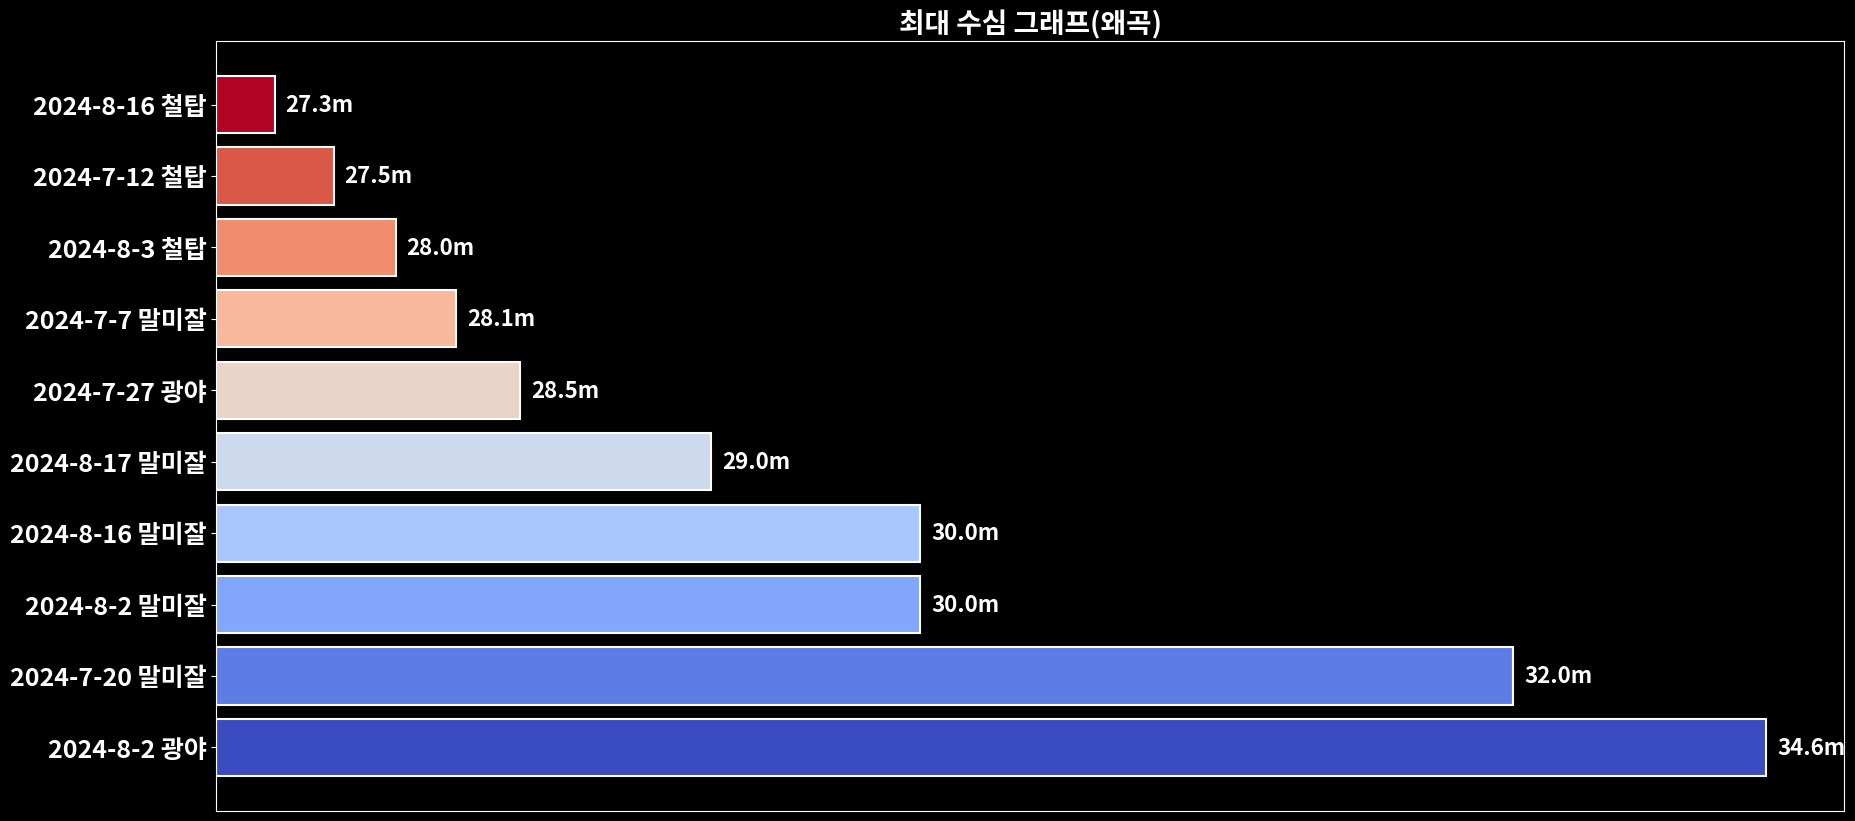

In [39]:


# 데이터 생성
data = {
    "Filename": [
        "2024-8-2 12-15-6-광야.csv",
        "2024-7-20 11-11-21-말미잘.csv",
        "2024-8-2 14-45-19-말미잘.csv",
        "2024-8-16 12-51-9-말미잘.csv",
        "2024-8-17 11-40-23-말미잘.csv",
        "2024-7-27 13-55-45-광야.csv",
        "2024-7-7 11-43-34-말미잘.csv",
        "2024-8-3 12-36-8-철탑.csv",
        "2024-7-12 13-44-50-철탑.csv",
        "2024-8-16 10-31-55-철탑.csv"
    ],
    "Max Depth": [34.6, 32.0, 30.0, 30.0, 29.0, 28.5, 28.1, 28.0, 27.5, 27.3]
}

# 데이터프레임 생성
top_10_max_depths = pd.DataFrame(data)

# 변환 함수 정의
def distort_scale_v2(value):
    if value <= 27.3:
        return value * 0.1
    elif value <= 27.5:
        return value * 0.2
    elif value <= 28:
        return value * 0.3
    elif value <= 28.1:
        return value * 0.4
    elif value <= 28.5:
        return value * 0.5
    elif value <= 29:
        return value * 0.8
    elif value <= 30:
        return value * 1.1
    elif value <= 32:
        return value * 1.9
    elif value <= 35:
        return value * 2.1
    return value

# Distorted Max Depth 열 추가
top_10_max_depths["Distorted Max Depth"] = top_10_max_depths["Max Depth"].apply(distort_scale_v2)

# 그래프 시작
plt.figure(figsize=(21, 10))
plt.gca().axes.get_xaxis().set_visible(False)

# 색상 정의
colors = plt.cm.coolwarm(np.linspace(0, 1, len(top_10_max_depths)))

# 가로 막대 그래프
plt.barh(
    top_10_max_depths["Filename"].apply(lambda x: f'{x.split(" ")[0]} {x.split("-")[-1].split(".")[0]}'),
    top_10_max_depths["Distorted Max Depth"],
    color=colors,
    edgecolor="white",
    linewidth=1.5
)

# 값 텍스트 추가 (막대 바로 오른쪽)
for index, value in enumerate(top_10_max_depths["Max Depth"]):
    plt.text(
        top_10_max_depths["Distorted Max Depth"][index] + 0.5,
        index,
        f'{value:.1f}m',
        va='center',
        ha='left',
        fontsize=16,
        fontweight='bold',
        color='white'
    )

# 축 레이블 및 제목

plt.yticks( fontsize=18, fontweight="bold")
plt.title("최대 수심 그래프(왜곡)", fontsize=20, fontweight="bold")



# 배경 스타일 조정
plt.gca().set_facecolor("black")

# 그래프 출력
plt.show()


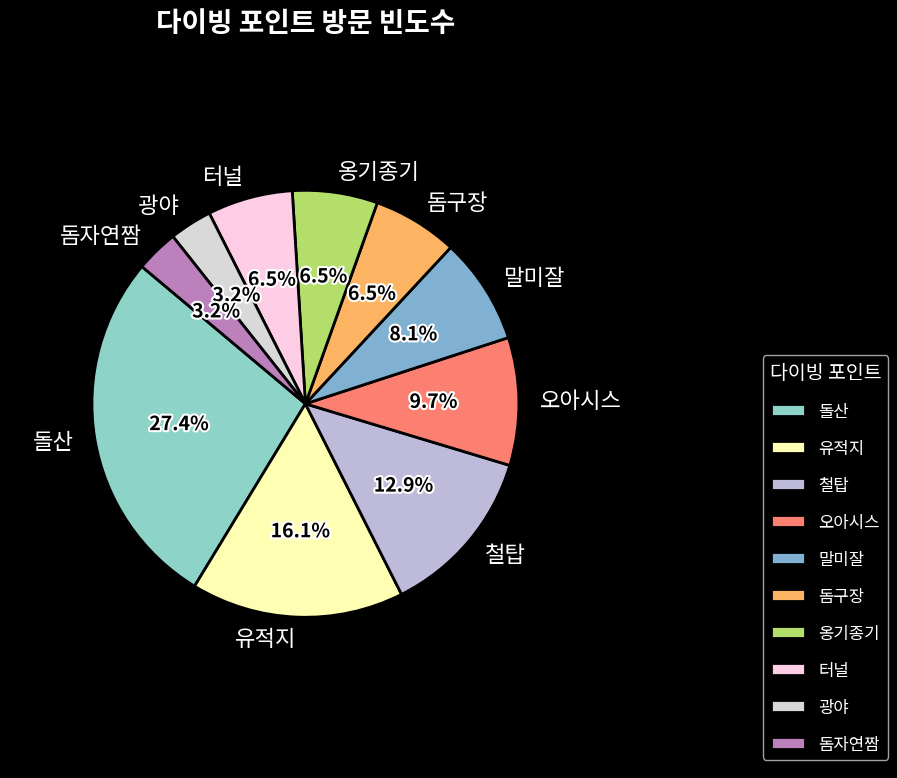

In [40]:
 # 각 폴더에 있는 파일 갯수 계산 및 원차트 시각화
folder_file_counts = {k: v for k, v in sorted({folder: len([f for f in os.listdir(os.path.join(base_folder, folder)) if f.endswith('.csv')]) for folder in folders}.items(), key=lambda item: item[1], reverse=True)}

# 원차트 시각화
plt.figure(figsize=(10, 8))
plt.style.use('dark_background')  # 배경을 어둡게 설정하여 프레젠테이션 스타일과 비슷하게 변경

wedges, texts, autotexts = plt.pie(
    folder_file_counts.values(),
    labels=folder_file_counts.keys(),
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Set3.colors,  # 가독성을 위해 컬러 팔레트 변경
    wedgeprops={'edgecolor': 'black', 'linewidth': 2}  # 각 조각의 테두리 추가
)

# 제목 스타일 조정
plt.title('다이빙 포인트 방문 빈도수', fontsize=20, fontweight='bold', loc='center', color='white')
plt.axis('equal')  # 원형 비율을 유지

# 텍스트 안쪽에 넣기 위한 설정 및 선 추가
for text in texts:
    text.set_fontsize(16)
    text.set_color('white')
for autotext in autotexts:
    autotext.set_fontsize(14)
    autotext.set_color('black')
    autotext.set_fontweight('bold')
    autotext.set_path_effects([path_effects.withStroke(linewidth=3, foreground='white')])  # 글자 테두리 추가로 가독성 향상

# 범례 추가
plt.legend(wedges, folder_file_counts.keys(), title="다이빙 포인트", loc="lower right", bbox_to_anchor=(1, 0, 0.5, 1), fontsize=12, title_fontsize=14, labelspacing=1.2)

plt.tight_layout()
plt.show()


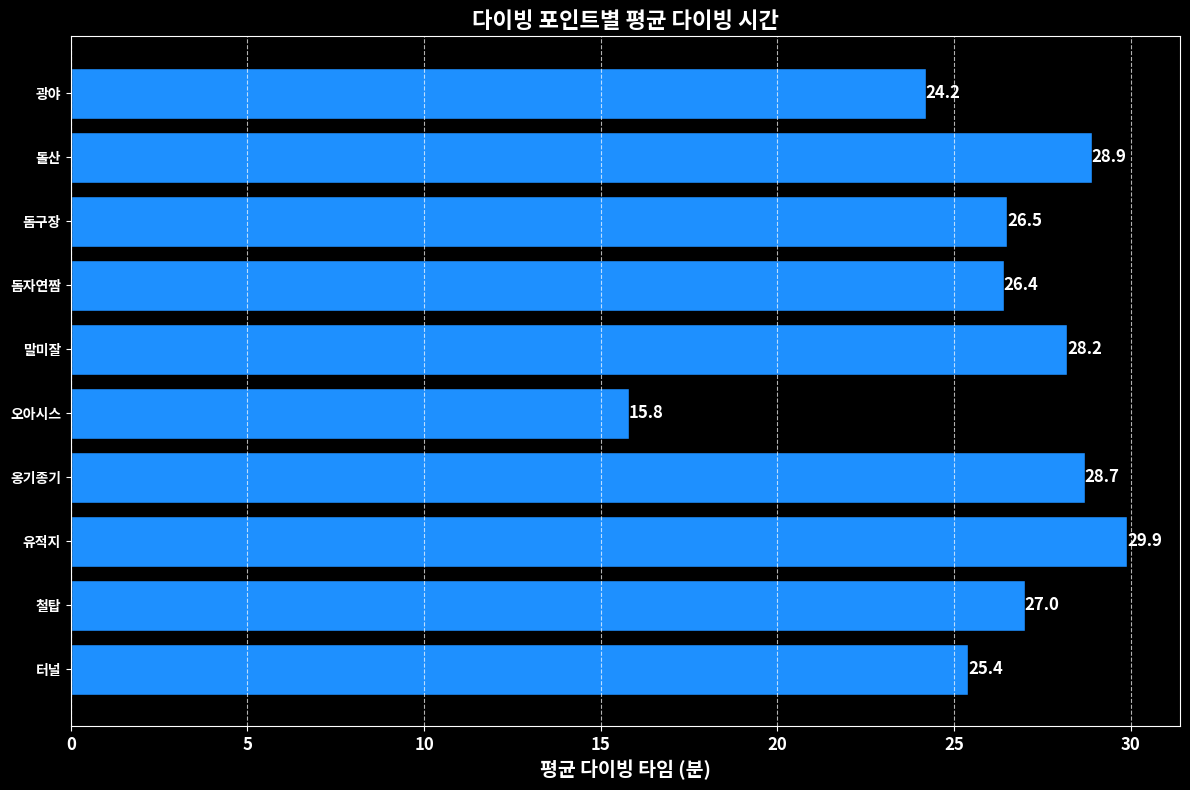

In [41]:
# 폴더별 평균 다이빙 시간 계산 및 시각화
folder_avg_diving_times = {}
for folder in folders:
    folder_diving_times = [time for file, time in diving_times if folder in file]
    if folder_diving_times:
        folder_avg_diving_times[folder] = round(sum(folder_diving_times) / len(folder_diving_times), 1)

# 시각화 추가
plt.figure(figsize=(12, 8))
plt.barh(list(folder_avg_diving_times.keys()), list(folder_avg_diving_times.values()), color='dodgerblue', edgecolor='black')

# 막대 끝에 수치 추가
for index, value in enumerate(folder_avg_diving_times.values()):
    plt.text(value, index, f'{value:.1f}', va='center', fontsize=12, color='white', fontweight='bold')
plt.xlabel('평균 다이빙 타임 (분)', fontsize=14,fontweight='bold')
plt.title('다이빙 포인트별 평균 다이빙 시간', fontsize=16, fontweight='bold')
plt.xticks(fontsize=12,fontweight='bold')
plt.yticks(fontsize=10,fontweight='bold')
plt.gca().invert_yaxis()  # 큰 값이 위로 오도록 설정
plt.grid(axis='x', linestyle='--', alpha=0.7)  # 가독성을 위한 그리드 추가
plt.tight_layout()
plt.show()


In [44]:
# "철탑"을 포함하는 파일명 필터링
filtered_diving_times = diving_times_df[diving_times_df["Filename"].str.contains("철탑")]

# 결과 출력
print(filtered_diving_times)

                          Filename  Diving Time
50   #142 2024-8-4 11-28-52-철탑.csv    27.533333
51  #124 2024-7-27 11-18-36-철탑.csv    30.733333
52  #154 2024-8-16 10-31-55-철탑.csv    32.216667
53   #114 2024-7-19 15-11-9-철탑.csv    27.150000
54  #105 2024-7-12 13-44-50-철탑.csv    25.350000
55  #117 2024-7-20 13-40-23-철탑.csv    27.633333
56   #145 2024-8-8 14-15-32-철탑.csv    29.366667
57    #140 2024-8-3 12-36-8-철탑.csv    15.783333


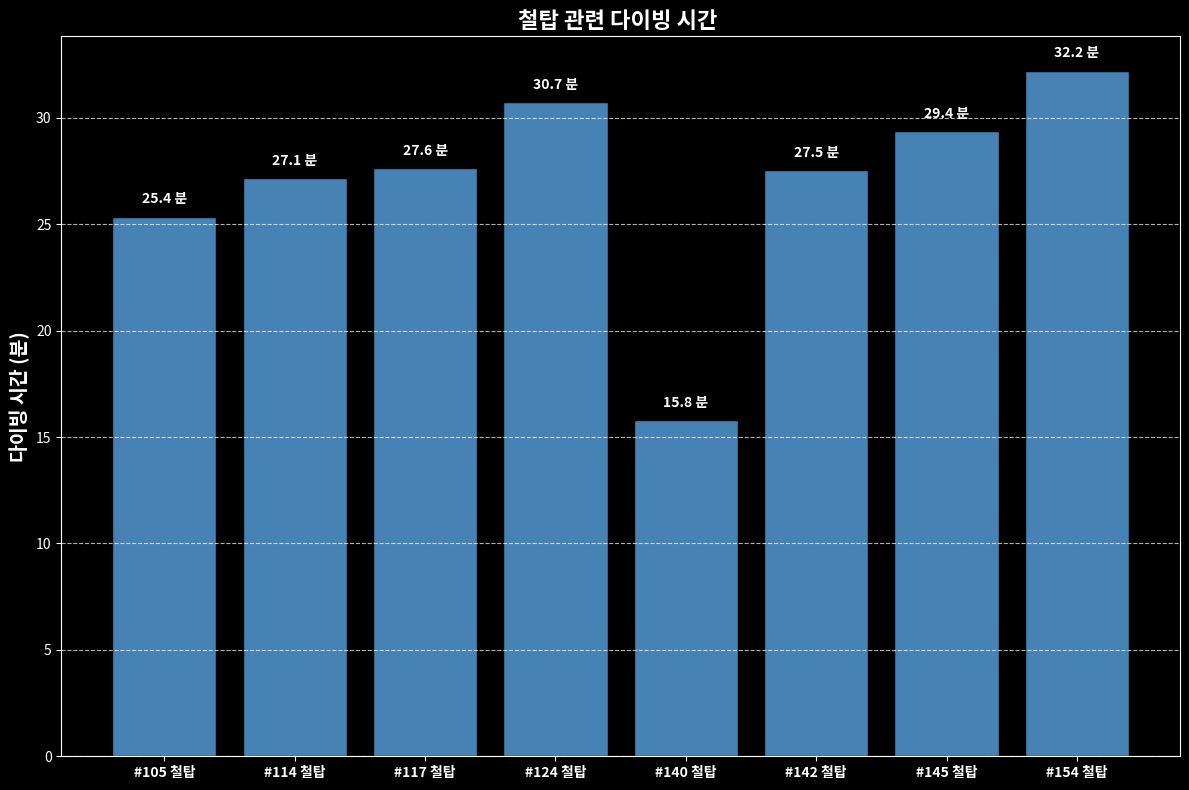

In [63]:
# 파일 이름을 간결하게 변환
filtered_diving_times["Formatted Filename"] = filtered_diving_times["Filename"].apply(
    lambda x: f'{x.split(" ")[0]} {x.split("-")[-1].split(".")[0]}'
)

# 파일 이름 순서로 정렬
filtered_diving_times = filtered_diving_times.sort_values("Formatted Filename")

# 그래프 크기 설정
plt.figure(figsize=(12, 8))

# 세로 막대 그래프 생성
plt.bar(
    filtered_diving_times["Formatted Filename"],
    filtered_diving_times["Diving Time"],
    color='steelblue',
    edgecolor='black'
)

# 막대 위에 값 표시
for index, value in enumerate(filtered_diving_times["Diving Time"]):
    plt.text(
        index,          # x 좌표: 막대의 중심
        value + 0.5,    # y 좌표: 막대 위 약간의 여백
        f'{value:.1f} 분',  # 표시할 텍스트
        ha='center',    # 수평 정렬: 중앙
        va='bottom',    # 수직 정렬: 아래
        fontsize=10,    # 글자 크기
        color='white',  # 글자 색상
        fontweight='bold'  # 글자 굵기
    )

# 축 및 제목 설정

plt.ylabel('다이빙 시간 (분)', fontsize=14, fontweight='bold')
plt.title('철탑 관련 다이빙 시간 ', fontsize=16, fontweight='bold')

# x축 레이블 가독성 향상을 위한 회전
plt.xticks(fontsize=10, ha='center', fontweight='bold')

# 그리드 추가 및 레이아웃 조정
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# 그래프 표시
plt.show()
